In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
DATA_PATH = Path("../data/processed")

analysis_ready = pd.read_csv(
    DATA_PATH / "analysis_ready.csv"
)

analysis_ready["date"] = pd.to_datetime(
    analysis_ready["date"]
)

print("Dataset loaded successfully!")
print("Shape:", analysis_ready.shape)

Dataset loaded successfully!
Shape: (365200, 21)


In [3]:
print("Total Units Sold:", analysis_ready["units_sold"].sum())
print("Total Revenue:", analysis_ready["revenue"].sum())
print("Average Daily Units:", analysis_ready["units_sold"].mean())
print("Average Unit Price:", analysis_ready["unit_price"].mean())

Total Units Sold: 5696318
Total Revenue: 11840586141.59
Average Daily Units: 15.597803943044907
Average Unit Price: 2240.9371936473167


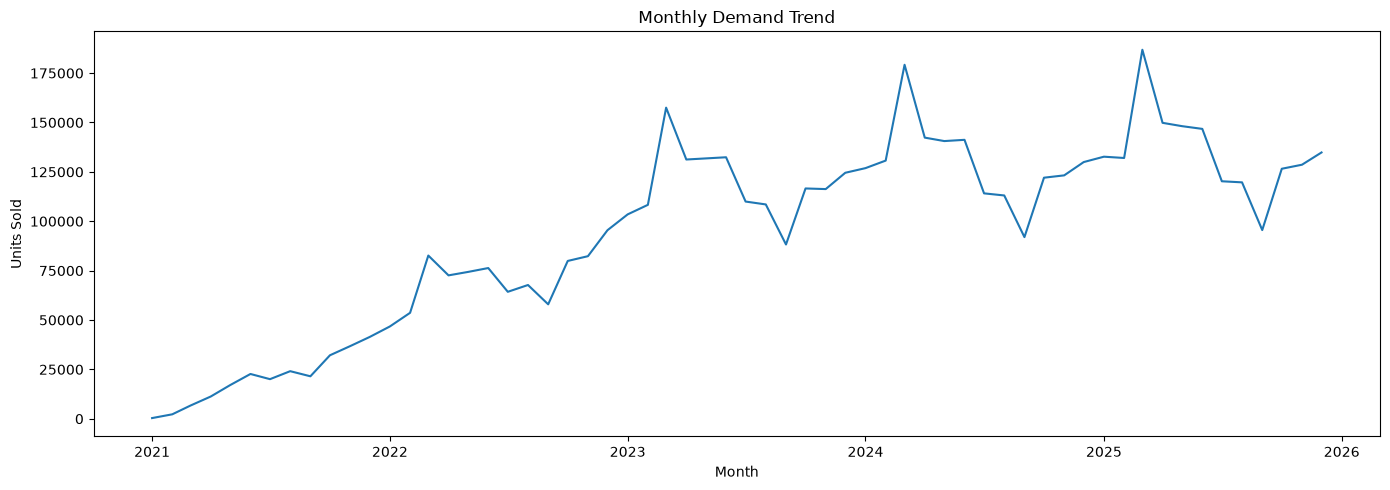

In [ ]:
monthly_sales = (
    analysis_ready
    .groupby(analysis_ready["date"].dt.to_period("M"))["units_sold"]
    .sum()
)

monthly_sales.index = monthly_sales.index.to_timestamp()

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales.index, monthly_sales.values)
plt.title("Monthly Demand Trend")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
top_skus = (
    analysis_ready
    .groupby("sku")["units_sold"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_skus)

sku
SKU0182    134753
SKU0039    117398
SKU0169    103352
SKU0018    102615
SKU0031    101984
SKU0168     99030
SKU0099     94721
SKU0097     84998
SKU0073     77737
SKU0022     77111
Name: units_sold, dtype: int64


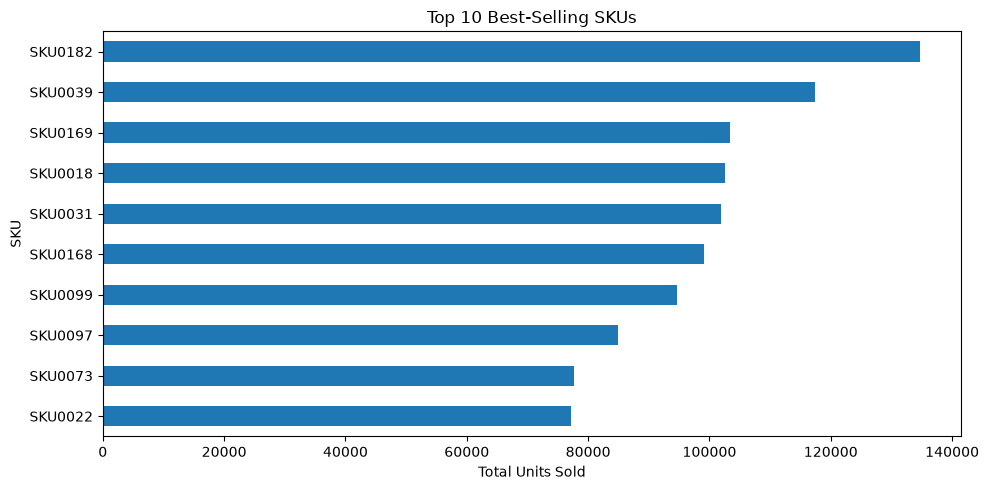

In [6]:
plt.figure(figsize=(10, 5))
top_skus.sort_values().plot(kind="barh")
plt.title("Top 10 Best-Selling SKUs")
plt.xlabel("Total Units Sold")
plt.ylabel("SKU")
plt.tight_layout()
plt.show()

In [8]:
category_sales = (
    analysis_ready
    .groupby("category")["units_sold"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

category
Lifestyle     739328
Kitchen       682148
Office        665171
Furniture     644635
Home Decor    614182
Storage       614100
Lighting      534555
Bath          525139
Bedding       364960
Outdoor       312100
Name: units_sold, dtype: int64


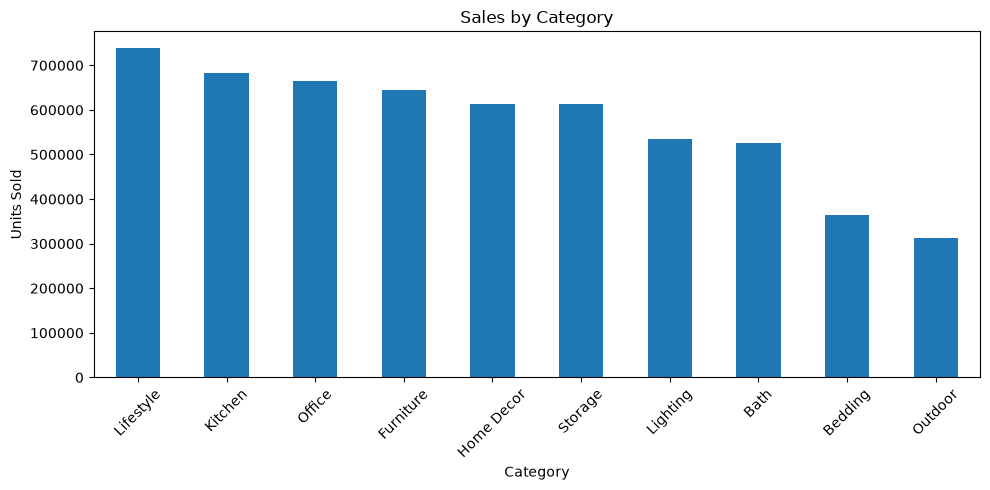

In [9]:
plt.figure(figsize=(10, 5))
category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
season_sales = (
    analysis_ready
    .groupby("season")["units_sold"]
    .sum()
    .sort_values(ascending=False)
)

print(season_sales)

season
Spring     1632170
Summer     1381121
Winter     1363323
Monsoon    1319704
Name: units_sold, dtype: int64


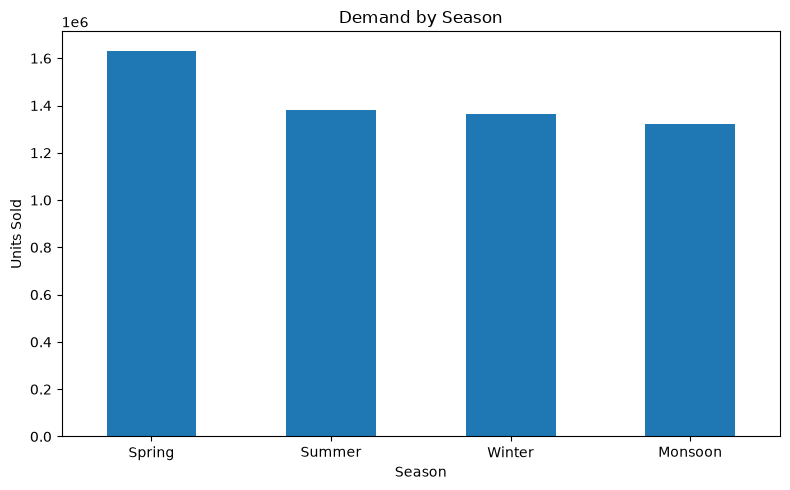

In [11]:
plt.figure(figsize=(8, 5))
season_sales.plot(kind="bar")
plt.title("Demand by Season")
plt.xlabel("Season")
plt.ylabel("Units Sold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
promotion_sales = (
    analysis_ready
    .groupby("promotion_flag")["units_sold"]
    .mean()
)

print(promotion_sales)

promotion_flag
0    14.425312
1    20.816269
Name: units_sold, dtype: float64


In [13]:
sku_demand = (
    analysis_ready
    .groupby("sku")["units_sold"]
    .sum()
    .sort_values()
)

print("Lowest-selling SKUs:")
print(sku_demand.head(20))

Lowest-selling SKUs:
sku
SKU0080     24
SKU0085     26
SKU0179     27
SKU0059     51
SKU0043     52
SKU0164     53
SKU0191     57
SKU0036     59
SKU0106     68
SKU0188     73
SKU0103     82
SKU0194     92
SKU0063     99
SKU0075    103
SKU0107    106
SKU0091    117
SKU0049    131
SKU0152    133
SKU0034    149
SKU0054    152
Name: units_sold, dtype: int64


In [14]:
dead_stock = sku_demand[sku_demand <= 100]

slow_movers = sku_demand[
    (sku_demand > 100) & (sku_demand <= 1000)
]

print("Dead Stock SKUs:", len(dead_stock))
print("Slow-Moving SKUs:", len(slow_movers))

Dead Stock SKUs: 13
Slow-Moving SKUs: 7
